In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)

df = pd.read_csv('fill/train.csv')
test_df = pd.read_csv('fill/test.csv')  # test 데이터 로드
print(df.shape, test_df.shape)

df['bmi'] = (df['weight'] / ((df['height'] / 100.0) ** 2)).round(2)
test_df['bmi'] = (test_df['weight'] / ((test_df['height'] / 100.0) ** 2)).round(2)

print(df.shape, test_df.shape)  
X = df.drop(columns=['stress_score']) 
y = df['stress_score']


(3000, 25) (3000, 24)
(3000, 26) (3000, 25)


In [2]:
df

,gender,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,activity,sleep_pattern,edu_level,mean_working,stress_score,mh_Unknown,mh_diabetes,mh_heart disease,mh_high blood pressure,fmh_Unknown,fmh_diabetes,fmh_heart disease,fmh_high blood pressure,smo_0,smo_1,smo_2,bmi
0,0,72,161.49,58.47,279.84,165,100,143.35,0.87,1,0,2,0.0,0.63,0,0,0,1,0,1,0,0,0,1,0,22.42
1,1,88,179.87,77.60,257.37,178,111,146.94,0.07,1,1,3,0.0,0.83,1,0,0,0,0,1,0,0,0,1,0,23.99
2,1,47,182.47,89.93,226.66,134,95,142.61,1.18,0,1,1,9.0,0.70,1,0,0,0,1,0,0,0,0,1,0,27.01
3,1,69,185.78,68.63,206.74,158,92,137.26,0.48,2,2,3,0.0,0.17,0,0,0,1,1,0,0,0,0,1,0,19.88
4,0,81,164.63,71.53,255.92,171,116,129.37,0.34,1,0,2,0.0,0.36,0,1,0,0,0,1,0,0,0,1,0,26.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,87,174.43,77.14,233.31,176,111,134.71,0.20,0,2,0,0.0,0.02,1,0,0,0,1,0,0,0,1,0,0,25.35
2996,1,25,171.44,51.67,196.89,143,86,111.91,1.75,1,1,1,9.0,0.16,1,0,0,0,1,0,0,0,0,0,1,17.58
2997,0,54,162.13,55.54,210.52,164,91,136.47,0.80,0,1,0,9.0,0.16,1,0,0,0,1,0,0,0,0,0,1,21.13
2998,1,70,181.32,82.20,234.10,182,91,144.89,0.58,1,2,1,0.0,0.18,1,0,0,0,1,0,0,0,1,0,0,25.00


# SVM

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.svm import SVR
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler


In [7]:

def tune_svr_rbf_mae_cv(X, y, max_evals=60, n_splits=5, random_state=42): 
    # ndarray로 맞춤
    X_arr = X.values if hasattr(X, "values") else np.asarray(X)
    y_arr = y.values if hasattr(y, "values") else np.asarray(y)

    def objective(params):
        # 연속형 그대로 사용 (정수 캐스팅 불필요)
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        fold_maes = []

        for tr_idx, val_idx in kf.split(X_arr):
            X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
            y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]

            # 폴드 안에서 스케일링 + 타깃 스케일링(안정성↑)
            pipe = make_pipeline(
                RobustScaler(),
                TransformedTargetRegressor(
                    regressor=SVR(
                        kernel="rbf",
                        C=params["C"],
                        gamma=params["gamma"],
                        epsilon = 0.0,  # 고정값, 타깃 스케일링 기준
                        shrinking=True,
                        cache_size=500,   # MB, 속도 도움
                        max_iter=-1
                    ),
                   transformer=QuantileTransformer(output_distribution="normal",
                                        n_quantiles=min(1000, len(y_tr)))
                )
            )

            pipe.fit(X_tr, y_tr)
            pred = pipe.predict(X_val)
            fold_maes.append(mean_absolute_error(y_val, pred))

        mean_mae = float(np.mean(fold_maes))
        return {"loss": mean_mae, "status": STATUS_OK}

    # 탐색 공간 (실전형)
    bestC, bestG = 3.2921101346679285, 0.39164577291716846

    space_refine = {
        "C":       hp.loguniform("C",     np.log(max(1e-2, bestC/3)), np.log(bestC*3)),   # ~[1.04, 9.34]
        "gamma":   hp.loguniform("gamma", np.log(max(1e-4, bestG/3)), np.log(bestG*4)),   # ~[0.167, 1.504]
    }
    trials = Trials()
    best = fmin(
        fn=objective,
        space=space_refine,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(random_state),
    )

    best_params = {
        "C":       float(best["C"]),
        "gamma":   float(best["gamma"]),
        "kernel":  "rbf"
    }

    best_mae = float(min(r["loss"] for r in trials.results))

    return {
        "best_params": best_params,
        "best_cv_mae": best_mae,
        "trials": trials, 
        "best": best
    }


In [8]:
summary = tune_svr_rbf_mae_cv(X,
                         y, 
                          max_evals=80,  
                          n_splits=10) 
print("CV MAE:", summary["best_cv_mae"])
print("Best params:", summary["best_params"])


  0%|          | 0/80 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 80/80 [05:32<00:00,  4.16s/trial, best loss: 0.13837972172947297]
CV MAE: 0.13837972172947297
Best params: {'C': 3.72688623422501, 'gamma': 1.0766560629541184, 'kernel': 'rbf'}


# 현재 vac 계정은 train 데이터에 robust를 한 결과이다 
+ 100%|██████████| 80/80 [04:56<00:00,  3.71s/trial, best loss: 0.13835681716176315]
+ CV MAE: 0.13835681716176315
+ Best params: {'C': 3.963530707518144, 'gamma': 1.0631617004546035, 'kernel': 'rbf'}

train mae: 3.3333333333333363e-06


<Axes: >

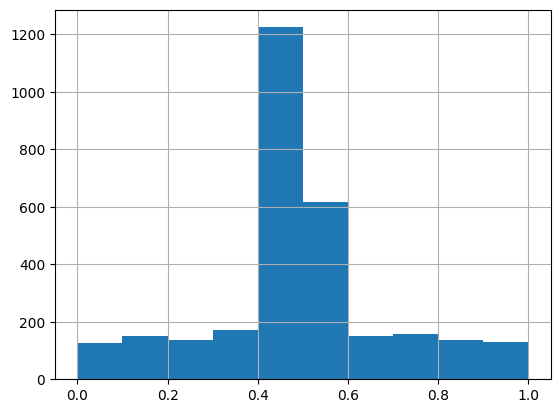

In [ ]:
Best_params =  {'C': 3.963530707518144, 'gamma': 1.0631617004546035, 'kernel': 'rbf','epsilon' : 0.00}   # 예시로 직접 지정 (튜닝 결과 사용 가능)


pipe = make_pipeline(
    RobustScaler(),  # X 스케일
    TransformedTargetRegressor(  # y 스케일 
        regressor=SVR(**Best_params),
         transformer=QuantileTransformer(output_distribution="normal",
                                        n_quantiles=min(1000, len(y)))
    )
)

# 학습
pipe.fit(X, y)

# 학습 MAE 확인 (과적합 점검용)
print("train mae:", mean_absolute_error(y, pipe.predict(X)))


# 테스트 예측 + 제출 저장
pred = pipe.predict(test_df)
submit = pd.read_csv("open/sample_submission.csv")
submit["stress_score"] = pred
submit.to_csv("robust_train_검증.csv", index=False)
submit["stress_score"].hist()